In [62]:
# ===============================================================
# Compare Pushforward Models vs pCN Posterior in KL Coordinates
# ===============================================================
import os, torch, numpy as np, h5py, scipy.io as sio, matplotlib.pyplot as plt
from scipy.stats import norm
from utilities import MatReader
from FNOmodel import CosineFNO1d, FNOTripletAdapter1d   # adjust import paths
from scipy.stats import gaussian_kde

# from FNOmodel import CosineFNO2d, FNOTripletAdapter
pushforwardtype = "fromprior"
if pushforwardtype =="fromjoint":
    from FNOmodel import *
    Cin=3
elif pushforwardtype=="fromprior":
    from FNOmodel_2inputchannel import *
    Cin=2

from scipy.spatial.distance import cdist

def energy_distance_mc(X, Y, n_xy=5000, n_xx=5000, n_yy=5000,seed=None):
    rng = np.random.default_rng(seed)
    # X–Y pairs
    i = rng.integers(0, len(X), size=n_xy)
    j = rng.integers(0, len(Y), size=n_xy)
    d_xy = np.linalg.norm(X[i] - Y[j], axis=1).mean()

    # X–X pairs
    i = rng.integers(0, len(X), size=n_xx)
    j = rng.integers(0, len(X), size=n_xx)
    d_xx = np.linalg.norm(X[i] - X[j], axis=1).mean()

    # Y–Y pairs
    i = rng.integers(0, len(Y), size=n_yy)
    j = rng.integers(0, len(Y), size=n_yy)
    d_yy = np.linalg.norm(Y[i] - Y[j], axis=1).mean()

    return 2*d_xy - d_xx - d_yy
    

In [63]:
sigma_obs = 1e-3
DEBUG=True
Nsol, Nobs = 64, 8 
tau = 3.0
alpha = 2.0
thin=100 # take every thin sample of pCN

In [64]:
# -------------------------------
# Configuration
# -------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
pushforward_paths = {
    "T_prior_best" : "./../../Models/fromprior_CosineFNO_cmON_fromprior_w80_m32_d5_B150_lr1e-3_E60_s42_641D_20260601_0524.pth",
    }
iteration_data=0 # For the first figure of the paper neither the file_true nor the pCN_chain_dir had iteration_data
file_data = "./../../Data/Experiment3/darcy_data1D_64.mat"
# file_true = "./../../Data/Experiment3/darcy_single_sample"+str(iteration_data)+".npz"
# pCN_chain_dir = "./../../Data/Experiment3/pcn_chain_indexdata"+str(iteration_data)+".npz"

file_true = "./../../Data/Experiment3/darcy_single_sample.npz"
pCN_chain_dir = "./../../Data/Experiment3/pcn_chain.npz"

In [65]:
string_models=["T_prior_best"]
CM_on_or_off="ON"

In [66]:
# -------------------------------
# Load Data (x,y)
# -------------------------------
with h5py.File(file_data, "r") as f:
    x = np.array(f["x"])  # (64,N)
    y = np.array(f["y"])  # (8,N)
np.random.seed(1373)
y_noisy = y + np.random.normal(0, sigma_obs, size=y.shape)
n_total = x.shape[-1]
half = (n_total) // 2
debeug_length=20000
if DEBUG==True:
    x_joint = x[:, half:half+debeug_length].T.astype(np.float32)
    y_joint = y_noisy[:,  half:half+debeug_length].T.astype(np.float32)
else:
    x_joint = x[:, half:].T.astype(np.float32)
    y_joint = y_noisy[:,  half:].T.astype(np.float32)


In [67]:
x_joint.shape

(20000, 64)

In [68]:
# -------------------------------
# Load true (x*, y†)
# -------------------------------
true_data = np.load(file_true)
x_true = true_data["u_true"].reshape(Nsol, 1)
y_dagger = true_data["y_obs"].reshape(Nobs, 1)

In [69]:
N=x_joint.shape[0]
y_dag_vec   = y_dagger.reshape(Nobs)              # (Nobs,)
y_dag_batch = np.repeat(y_dag_vec[None, :], N, axis=0)  # (N, Nobs)
# --- to torch ---
x_t      = torch.from_numpy(x_joint).float().to(device)
y_t      = torch.from_numpy(y_joint).float().to(device)
y_dag_t  = torch.from_numpy(y_dag_batch).float().to(device)


In [70]:

def build_phi_lambda(Nsol, tau, alpha):
    # grid points x_j = (2j - 1)/(2 Nsol),  j = 1..Nsol
    j = np.arange(1, Nsol + 1)
    x_spatial = (2*j - 1) / (2 * Nsol)   # shape (Nsol,)

    # mode indices i = 1..Nsol
    i = np.arange(1, Nsol + 1)   # shape (Nsol,)

    # Phi[j, i] = sqrt(2) * cos(i * pi * x_j)
    # Use broadcasting: x[:,None] (Nsol,1), i[None,:] (1,Nsol)
    Phi = np.sqrt(2.0) * np.cos(np.pi * x_spatial[:, None] * i[None, :])

    # lambda_i = ((i*pi)^2 + tau^2)^(-alpha)
    lambdas = ((i * np.pi)**2 + tau**2)**(-alpha)

    return x_spatial, Phi[:,:-1], lambdas[:-1]

x_spatial, Phi, lambdas = build_phi_lambda(Nsol, tau, alpha)


In [71]:
# checking if the eigenfunctions are calculated correctly. 
# The standard deviation of the samples should be sqrt of lambda along each eigen modes.
dx = 1.0 / Nsol
coeffs = dx * Phi.T @ x
# --- empirical std along each mode ----
std_emp = np.std(coeffs, axis=1, ddof=0)     # (Nsol,)
std_theory = np.sqrt(lambdas)                # (Nsol,)
rel_err = np.abs(std_emp - std_theory) / std_theory
print("Mode  EmpStd   ThStd   RelErr")
for k in range(Nsol-1):
    print(f"{k+1:3d}  {std_emp[k]:.4e}  {std_theory[k]:.4e}  {rel_err[k]:.3e}")


Mode  EmpStd   ThStd   RelErr
  1  5.3003e-02  5.2995e-02  1.539e-04
  2  2.0607e-02  2.0628e-02  1.014e-03
  3  1.0230e-02  1.0222e-02  7.962e-04
  4  5.9980e-03  5.9911e-03  1.152e-03
  5  3.9076e-03  3.9102e-03  6.775e-04
  6  2.7437e-03  2.7449e-03  4.438e-04
  7  2.0272e-03  2.0300e-03  1.401e-03
  8  1.5593e-03  1.5609e-03  1.024e-03
  9  1.2376e-03  1.2370e-03  4.900e-04
 10  1.0048e-03  1.0041e-03  6.971e-04
 11  8.3017e-04  8.3110e-04  1.126e-03
 12  6.9938e-04  6.9919e-04  2.663e-04
 13  5.9662e-04  5.9632e-04  5.118e-04
 14  5.1483e-04  5.1455e-04  5.468e-04
 15  4.4833e-04  4.4850e-04  3.851e-04
 16  3.9441e-04  3.9438e-04  8.319e-05
 17  3.4957e-04  3.4949e-04  2.270e-04
 18  3.1214e-04  3.1184e-04  9.397e-04
 19  2.7985e-04  2.7996e-04  4.115e-04
 20  2.5262e-04  2.5273e-04  4.078e-04
 21  2.2951e-04  2.2928e-04  9.894e-04
 22  2.0889e-04  2.0895e-04  2.700e-04
 23  1.9118e-04  1.9120e-04  1.157e-04
 24  1.7552e-04  1.7563e-04  5.815e-04
 25  1.6189e-04  1.6188e-04  6.246

In [72]:
# loading posterior samples:
pCNchain=np.load(pCN_chain_dir)["chain"].T
print("projection to the constant eigen mode is: " ,np.sum(np.mean(pCNchain,axis=1)) )
print("This needs to be zero because we have excluded that mode from the data")


projection to the constant eigen mode is:  -3.191891195797325e-14
This needs to be zero because we have excluded that mode from the data


Now its time to load the model, run the pushforward and then compare the distribution of the samples. Please work so that I can work on a new project.

In [73]:
thin_pCNchain = pCNchain[:,::thin]

In [74]:
pCNchain.shape

(64, 1000000)

In [75]:
Phi.shape

(64, 63)

In [76]:
np.mean(pCNchain)

np.float64(-2.1163626406917046e-22)

/tmp/ipykernel_1747058/1797181521.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(pushforward_paths[strings], map_location=device)


✅ Model loaded and ready for inference
(20000, 64) (20000, 8) (8, 1)
T_prior_best
pushforward_samples shape: torch.Size([20000, 64])


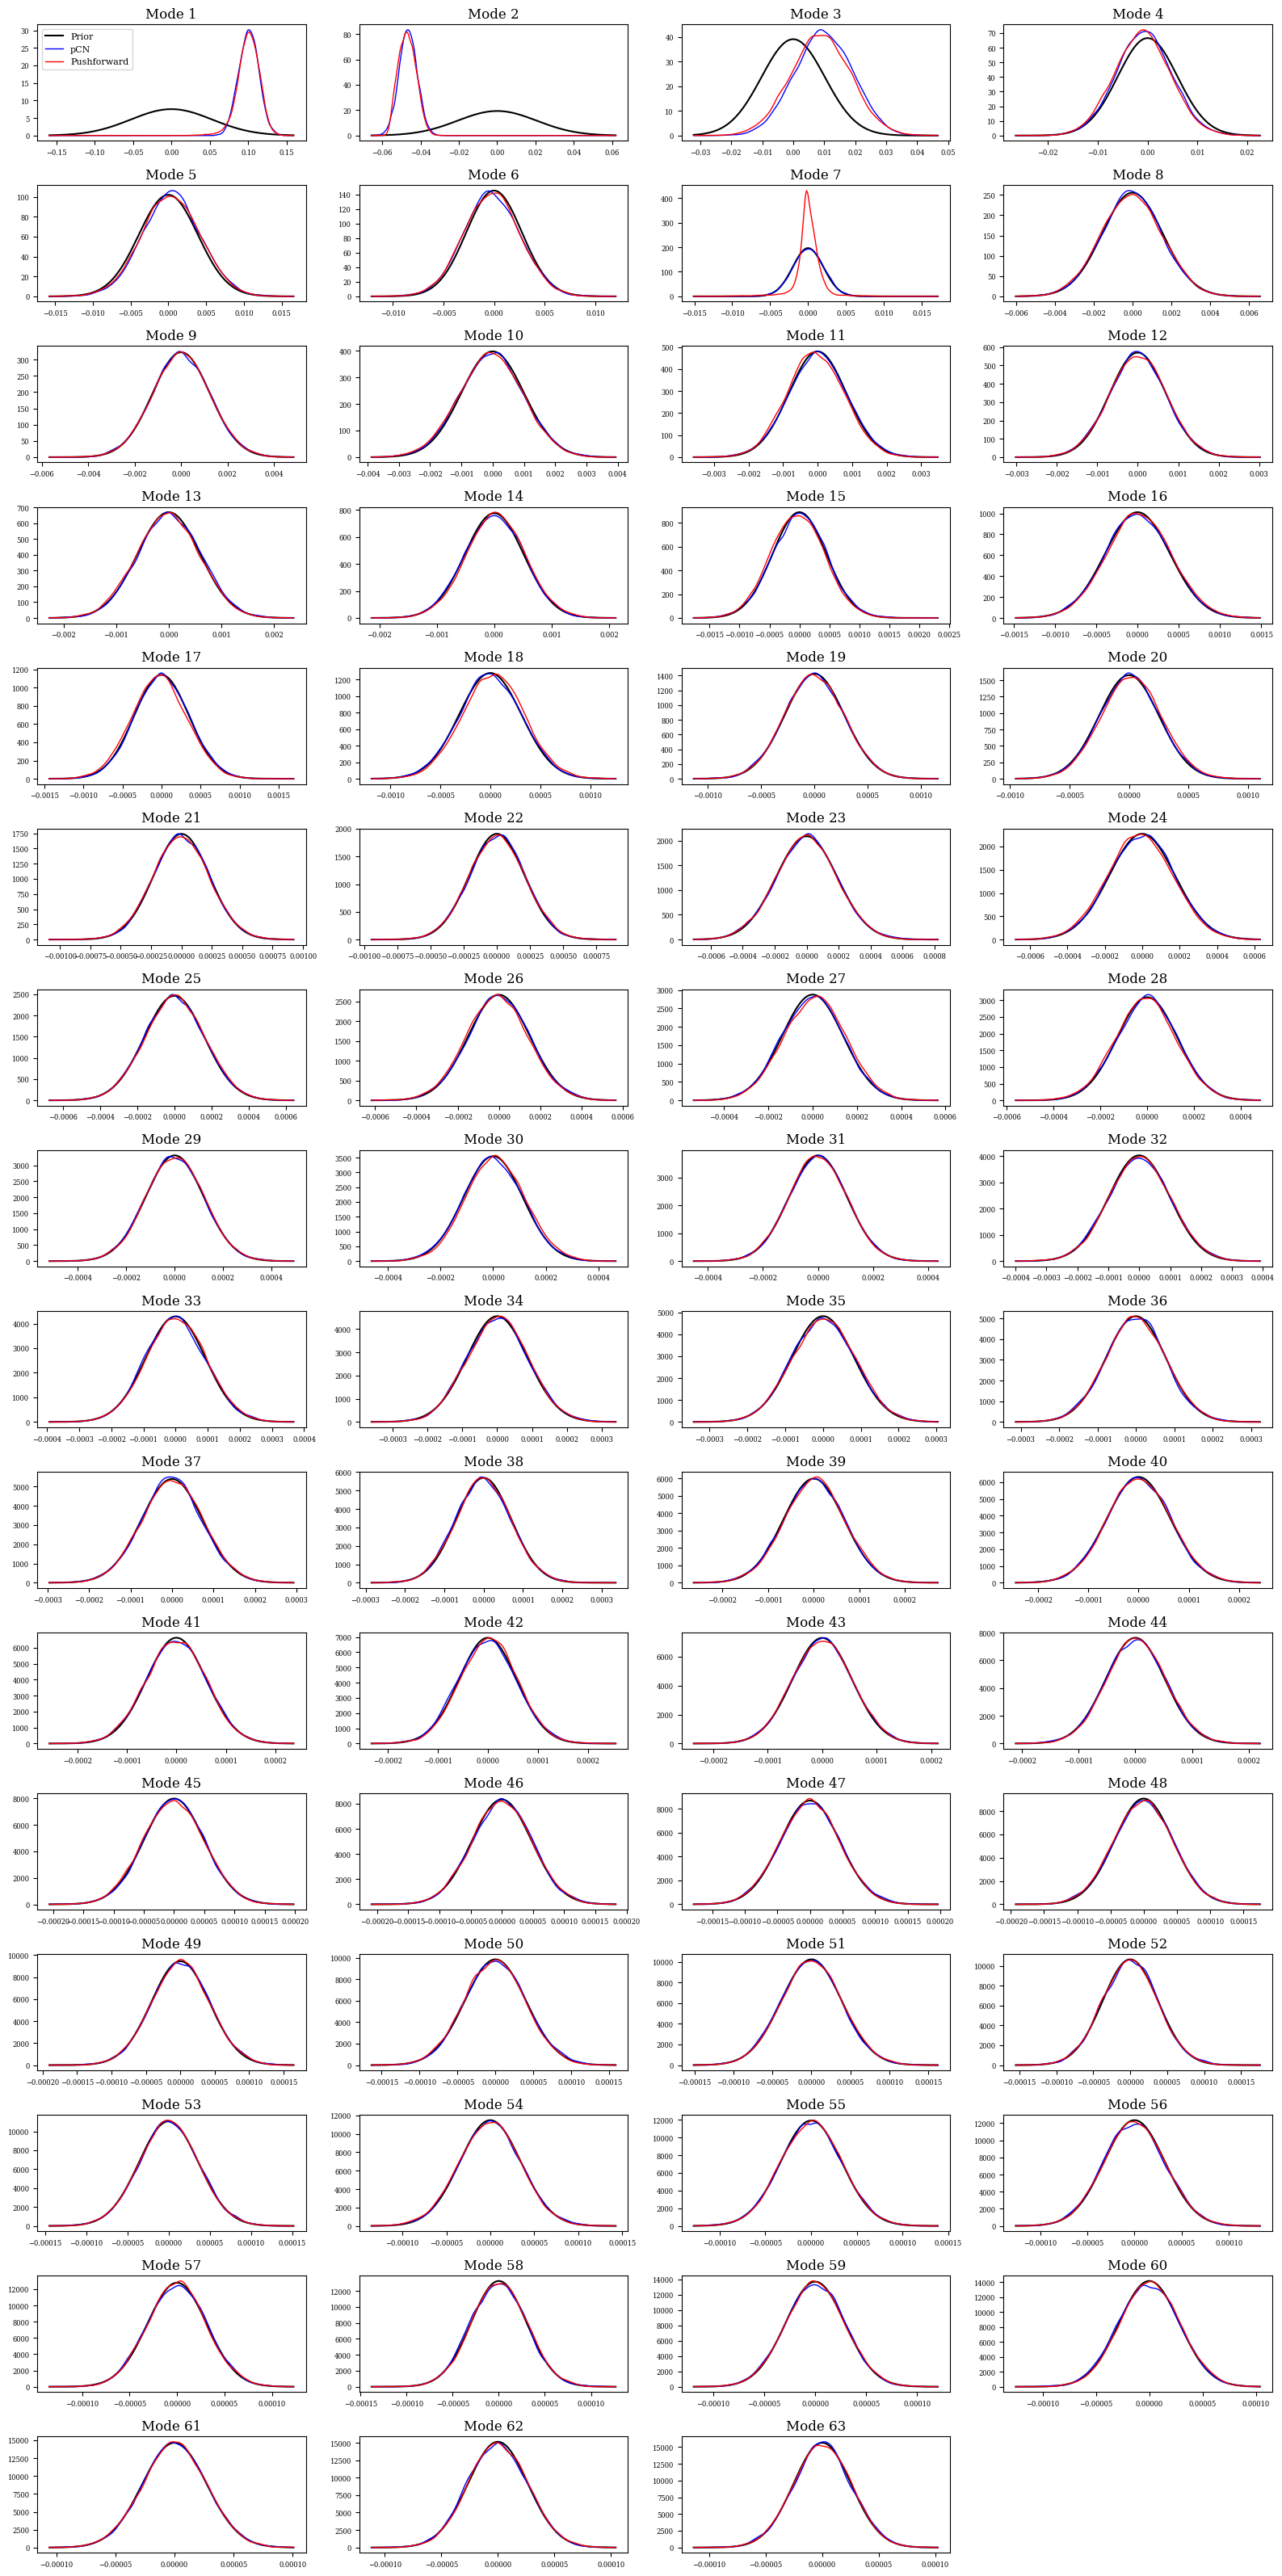

In [77]:
# -----------------------------------------
# Load checkpoint
# -----------------------------------------
from scipy.stats import wasserstein_distance
wasserstein_results = {}


for strings in string_models:
    ckpt = torch.load(pushforward_paths[strings], map_location=device)
    cfg = ckpt["config"]
    mean_std = ckpt["mean_std"]

    # -----------------------------------------
    # Rebuild base model
    # -----------------------------------------
    base = CosineFNO1d(
        Cin      = Cin,                     # <<< replace if different
        Cout     = 1,                     # <<< replace if different
        width    = cfg["width"],
        modes_x  = cfg["modes_x"],
        Lx       = 1.0,                   # <<< replace with your Lx
        depth    = cfg["depth"],
        use_cm   = cfg["use_cm"],
        cm_alpha = cfg["cm_alpha"],
        cm_tau   = cfg["cm_tau"],
        dropout  = cfg["dropout"],
    )

    # Wrap with correct adapter
    if cfg["pushforwardtype"] == "fromjoint":
        model = FNOTripletAdapter1d(
            base,
            mean_std['mean_u'], mean_std['std_u'],
            mean_std['mean_y'], mean_std['std_y']
        )
    else:
        model = FNO2Adapter1d(
            base,
            mean_std['mean_u'], mean_std['std_u'],
            mean_std['mean_y'], mean_std['std_y']
        )

    model = model.to(device)

    # -----------------------------------------
    # Load weights
    # -----------------------------------------
    model.load_state_dict(ckpt["model_state_dict"])

    model.eval()
    print("✅ Model loaded and ready for inference")
    print(x_joint.shape,y_joint.shape,y_dagger.shape)
    print(strings)
    with torch.no_grad():
        # For FNOTripletAdapter1d: (x_joint, y_joint, y_dag_batch)
        if cfg["pushforwardtype"] == "fromjoint":
            pushforward_samples = model(x_t, y_t, y_dag_t)   # shape depends on your adapter
        else:
            pushforward_samples = model(x_t, y_dag_t)
    out_path = f"./../../Data/Experiment3/pushforward_samples_{strings}"+"CM"+CM_on_or_off+".npz"
    # np.savez_compressed(
    #     out_path,
    #     pushforward_samples=pushforward_samples.detach().cpu().numpy(),   # shape (Nsol, N)
    #     x_true=x_true,
    #     y_dagger=y_dagger,
    #     sigma_obs=sigma_obs,
    #     config=cfg
    # )
    # print("✅ saved:", out_path)

    
    print("pushforward_samples shape:", pushforward_samples.shape)
    pushforward_samples=pushforward_samples.detach().cpu().numpy().T
    # find distance between two distribution (MCMC and the pushforward):
    # samples1=pushforward_samples.T
    # samples2=pCNchain.T
    # energy_distance_mc(samples1, samples2, n_xy=100000, n_xx=100000, n_yy=100000)

    dx = 1.0 / Nsol
    pcn_proj   = dx * Phi.T @ thin_pCNchain          # (Nmodes, Nsamp_pcn)
    push_proj  = dx * Phi.T @ pushforward_samples              # (Nmodes, Npush)


    n_modes_wass = pcn_proj.shape[0]
    wass_per_mode = []

    for i in range(n_modes_wass):
        pcn_i  = pcn_proj[i, :]
        push_i = push_proj[i, :]
        w_i = wasserstein_distance(pcn_i, push_i)
        wass_per_mode.append(w_i)

    wasserstein_results[strings] = {
        "per_mode": np.array(wass_per_mode),
        "mean": np.mean(wass_per_mode),
        "sum": np.sum(wass_per_mode),
    }



    n_rows, n_cols = 16, 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 32))
    axes = axes.ravel()
    # ---------------------------------------------------
    # 3) Loop over modes and plot prior + KDEs
    # ---------------------------------------------------
    for i in range(Nsol-1):  # 0..62 if Nmodes=63
        ax = axes[i]

        # Samples along mode i
        pcn_i   = pcn_proj[i, :]    # (Nsamp_pcn,)
        push_i  = push_proj[i, :]   # (Npush,)

        # Theoretical prior N(0, lambda_i)
        lam_i = lambdas[i]
        std_i = np.sqrt(lam_i)

        # Set x-range based on samples and theory
        all_vals = np.concatenate([pcn_i, push_i])
        x_min = min(all_vals.min(), -3*std_i)
        x_max = max(all_vals.max(),  3*std_i)
        xs = np.linspace(x_min, x_max, 200)

        # Prior density
        prior_pdf = (1.0 / (np.sqrt(2*np.pi)*std_i)) * np.exp(-0.5 * (xs/std_i)**2)
        ax.plot(xs, prior_pdf, 'k-', lw=1.5, label='Prior')

        # KDE for pCN samples
        kde_pcn = gaussian_kde(pcn_i)
        ax.plot(xs, kde_pcn(xs), 'b-', lw=1, label='pCN')

        # KDE for pushforward samples
        kde_push = gaussian_kde(push_i)
        ax.plot(xs, kde_push(xs), 'r-', lw=1, label='Pushforward')

        ax.set_title(f"Mode {i+1}")
        ax.tick_params(axis='both', labelsize=6)

    # Optional: add a single legend in the last axis
    axes[0].legend(fontsize=8)
    fig.delaxes(axes[-1])
    plt.tight_layout()
    # plt.savefig("modes_grid"+strings+".png", dpi=300)
    plt.show()



In [78]:
np.mean(pushforward_samples)

np.float32(-2.384186e-10)

In [79]:
# # ---------------------------------------------------
# # Plot first 6 modes only (2 rows × 3 columns)
# # ---------------------------------------------------
# Nmodes_plot = 6
# fig, axes = plt.subplots(2, 3, figsize=(9, 4))
# axes = axes.ravel()

# for i in range(Nmodes_plot):
#     ax = axes[i]

#     # Samples along mode i
#     pcn_i   = pcn_proj[i, :]
#     push_i  = push_proj[i, :]

#     # Theoretical prior N(0, lambda_i)
#     lam_i = lambdas[i]
#     std_i = np.sqrt(lam_i)

#     # x-range
#     all_vals = np.concatenate([pcn_i, push_i])
#     x_min = min(all_vals.min(), -3*std_i)
#     x_max = max(all_vals.max(),  3*std_i)
#     xs = np.linspace(x_min, x_max, 200)

#     # Prior density
#     prior_pdf = (1.0 / (np.sqrt(2*np.pi)*std_i)) * np.exp(-0.5 * (xs/std_i)**2)
#     ax.plot(xs, prior_pdf, 'k-', lw=1.5)

#     # KDE for pCN samples
#     kde_pcn = gaussian_kde(pcn_i)
#     ax.plot(xs, kde_pcn(xs), 'b-', lw=1)

#     # KDE for pushforward samples
#     kde_push = gaussian_kde(push_i)
#     ax.plot(xs, kde_push(xs), 'r-', lw=1)

#     # Instead of title → small label inside subplot
#     ax.text(0.05, 0.9, f"Mode {i+1}",
#             transform=ax.transAxes,
#             fontsize=10,
#             verticalalignment='top')

# # One legend only
# axes[0].legend(['Prior', 'pCN', 'Pushforward'], fontsize=9)

# plt.tight_layout()
# plt.savefig("./../../Figs/Experiment3/modes_grid_"+strings+".png", dpi=300)
# plt.show()

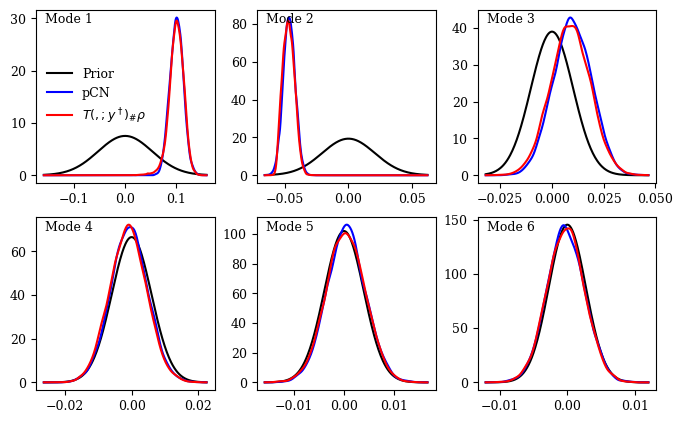

In [92]:
# -----------------------------------------
# Plot first 6 modes only, paper style
# -----------------------------------------
Nmodes_plot = 6
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

fig, axes = plt.subplots(2, 3, figsize=(6.8, 4.2))
axes = axes.ravel()

for i in range(Nmodes_plot):
    ax = axes[i]

    pcn_i  = pcn_proj[i, :]
    push_i = push_proj[i, :]

    lam_i = lambdas[i]
    std_i = np.sqrt(lam_i)

    all_vals = np.concatenate([pcn_i, push_i])
    x_min = min(all_vals.min(), -3.0 * std_i)
    x_max = max(all_vals.max(),  3.0 * std_i)
    xs = np.linspace(x_min, x_max, 300)

    # Prior
    prior_pdf = (1.0 / (np.sqrt(2*np.pi)*std_i)) * np.exp(-0.5 * (xs/std_i)**2)
    ax.plot(xs, prior_pdf, 'k-', label='Prior')

    # pCN
    kde_pcn = gaussian_kde(pcn_i)
    ax.plot(xs, kde_pcn(xs), 'b-', label='pCN')

    # Pushforward
    kde_push = gaussian_kde(push_i)
    ax.plot(xs, kde_push(xs), 'r-', label=r'$T(,;y^\dagger)_\#\rho$')

    # subplot label (paper style)
    ax.text(0.05, 0.98, f"Mode {i+1}",
            transform=ax.transAxes,
            fontsize=9,
            va='top')

    ax.tick_params(axis='both')

# One legend only
axes[0].legend(frameon=False,loc='center left',)

plt.tight_layout(pad=0.6)
plt.savefig("./../../Figs/Experiment3/modes_grid_"+strings+"CM"+CM_on_or_off+".png", dpi=300)
plt.show()

In [81]:
# for i in range(N):
#     plt.plot(pushforward_samples[:,i],color='black',alpha=.1)
# plt.plot(x_true,color='red')

In [82]:
# # Means & std
# pcn_mean  = pCNchain.mean(axis=1)
# pcn_std   = pCNchain.std(axis=1)

# push_mean = pushforward_samples.mean(axis=1)
# push_std  = pushforward_samples.std(axis=1)

# plt.figure(figsize=(6.8,5))

# # --- True ---
# plt.plot(x_spatial, x_true, 'r-', lw=2, label="True")

# # --- pCN mean + std lines ---
# plt.plot(x_spatial, pcn_mean, 'b-', lw=1.5, label="pCN mean")
# plt.plot(x_spatial, pcn_mean + pcn_std, 'b--', lw=1, label="pCN ±1σ")
# plt.plot(x_spatial, pcn_mean - pcn_std, 'b--', lw=1)
# # plt.plot(x_spatial, pcn_mean + 2*pcn_std, 'b:', lw=1, label="pCN ±2σ")
# # plt.plot(x_spatial, pcn_mean - 2*pcn_std, 'b:', lw=1)

# # --- pushforward mean + std lines ---
# plt.plot(x_spatial, push_mean, 'g-', lw=1.5, label="Push mean")
# plt.plot(x_spatial, push_mean + push_std, 'g--', lw=1, label="Push ±1σ")
# plt.plot(x_spatial, push_mean - push_std, 'g--', lw=1)


# plt.xlabel(r"$x$")
# plt.ylabel(r"$u(x)$")
# # plt.title("pCN vs Pushforward Uncertainty Bands")

# plt.legend()
# plt.xlim([0,1])
# plt.tight_layout()
# plt.savefig("./../../Figs/Experiment3/physical_space.png", dpi=300)

# plt.show()

In [83]:
X_obs = (2*np.arange(4, 65, 8) - 1) / (2*64)

In [84]:
strings

'T_prior_best'

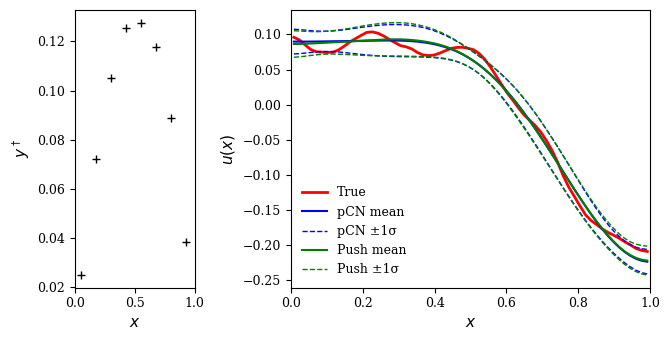

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------
# Paper font settings
# -----------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
})

# -----------------------------------------
# Means & std
# -----------------------------------------
pcn_mean  = pCNchain.mean(axis=1)
pcn_std   = pCNchain.std(axis=1)

push_mean = pushforward_samples.mean(axis=1)
push_std  = pushforward_samples.std(axis=1)

# -----------------------------------------
# Figure with 25% / 75% width split
# -----------------------------------------
fig = plt.figure(figsize=(6.8, 3.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 3])

ax_obs = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[0, 1])

# -----------------------------------------
# Left subplot: observations
# -----------------------------------------
ax_obs.plot(X_obs, y_dagger, "+", color="k")
ax_obs.set_ylabel(r"$y^\dagger$")
ax_obs.set_xlabel(r"$x$")
ax_obs.set_xlim([0, 1])

# -----------------------------------------
# Right subplot: physical space uncertainty
# -----------------------------------------
ax_main.plot(x_spatial, x_true, 'r-', lw=2, label="True")

ax_main.plot(x_spatial, pcn_mean, 'b-', label="pCN mean")
ax_main.plot(x_spatial, pcn_mean + pcn_std, 'b--', lw=1, label="pCN ±1σ")
ax_main.plot(x_spatial, pcn_mean - pcn_std, 'b--', lw=1)

ax_main.plot(x_spatial, push_mean, 'g-', label="Push mean")
ax_main.plot(x_spatial, push_mean + push_std, 'g--', lw=1, label="Push ±1σ")
ax_main.plot(x_spatial, push_mean - push_std, 'g--', lw=1)

ax_main.set_xlabel(r"$x$")
ax_main.set_ylabel(r"$u(x)$")
ax_main.set_xlim([0, 1])

ax_main.legend(frameon=False)

# -----------------------------------------
# Layout & save
# -----------------------------------------
plt.tight_layout()
plt.savefig("./../../Figs/Experiment3/physical_space_with_obs"+strings+"CM"+CM_on_or_off+"+iteration"+str(iteration_data)+".png", dpi=300, bbox_inches='tight')

plt.show()

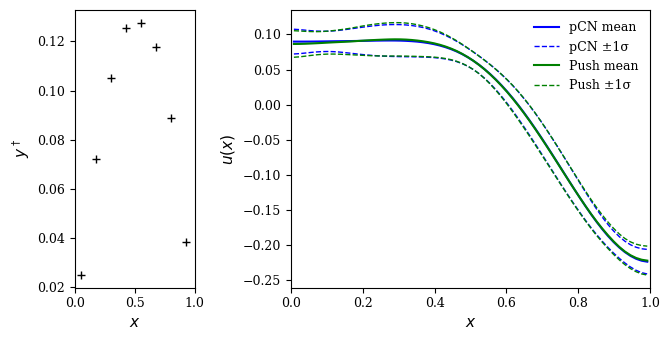

In [86]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------
# Paper font settings
# -----------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "lines.linewidth": 1.5,
})

# -----------------------------------------
# Means & std
# -----------------------------------------
pcn_mean  = pCNchain.mean(axis=1)
pcn_std   = pCNchain.std(axis=1)

push_mean = pushforward_samples.mean(axis=1)
push_std  = pushforward_samples.std(axis=1)

# -----------------------------------------
# Figure with 25% / 75% width split
# -----------------------------------------
fig = plt.figure(figsize=(6.8, 3.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 3])

ax_obs = fig.add_subplot(gs[0, 0])
ax_main = fig.add_subplot(gs[0, 1])

# -----------------------------------------
# Left subplot: observations
# -----------------------------------------
ax_obs.plot(X_obs, y_dagger, "+", color="k")
ax_obs.set_ylabel(r"$y^\dagger$")
ax_obs.set_xlabel(r"$x$")
ax_obs.set_xlim([0, 1])

# -----------------------------------------
# Right subplot: physical space uncertainty
# -----------------------------------------
# ax_main.plot(x_spatial, x_true, 'r-', lw=2, label="True")

ax_main.plot(x_spatial, pcn_mean, 'b-', label="pCN mean")
ax_main.plot(x_spatial, pcn_mean + pcn_std, 'b--', lw=1, label="pCN ±1σ")
ax_main.plot(x_spatial, pcn_mean - pcn_std, 'b--', lw=1)

ax_main.plot(x_spatial, push_mean, 'g-', label="Push mean")
ax_main.plot(x_spatial, push_mean + push_std, 'g--', lw=1, label="Push ±1σ")
ax_main.plot(x_spatial, push_mean - push_std, 'g--', lw=1)

ax_main.set_xlabel(r"$x$")
ax_main.set_ylabel(r"$u(x)$")
ax_main.set_xlim([0, 1])

ax_main.legend(frameon=False)

# -----------------------------------------
# Layout & save
# -----------------------------------------
plt.tight_layout()
plt.savefig("./../../Figs/Experiment3/physical_space_with_obs"+strings+"CM"+CM_on_or_off+"+iteration"+str(iteration_data)+"plotfortalk.png", dpi=300, bbox_inches='tight')

plt.show()

In [87]:
np.savez_compressed(f"./../../Data/Experiment3/wasserstein_{strings}CM"+CM_on_or_off+".npz", **wasserstein_results[strings])

In [88]:
strings

'T_prior_best'

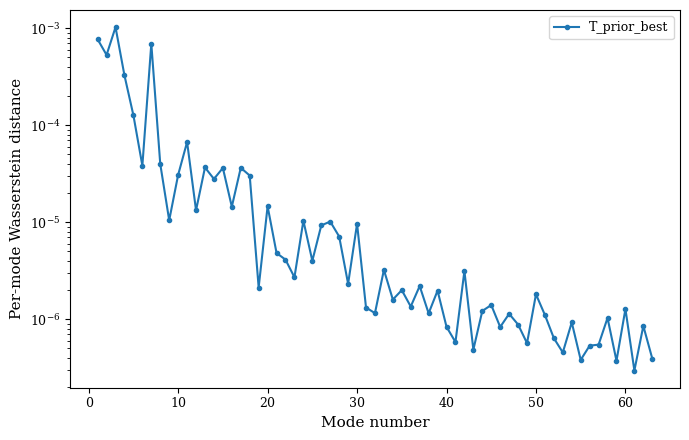

In [89]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,4.5))

for strings in string_models:
    per_mode = wasserstein_results[strings]["per_mode"]
    plt.plot(np.arange(1, len(per_mode)+1), per_mode, marker='o', ms=3, lw=1.5, label=strings)

plt.xlabel("Mode number")
plt.ylabel("Per-mode Wasserstein distance")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

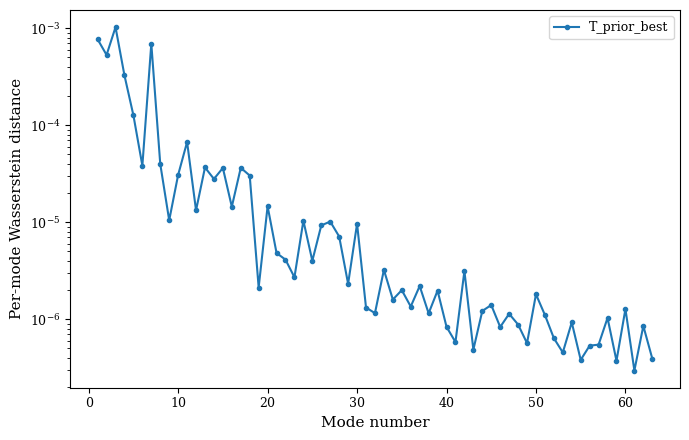

In [90]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,4.5))

for strings in string_models:
    per_mode = wasserstein_results[strings]["per_mode"]
    plt.plot(np.arange(1, len(per_mode)+1), per_mode, marker='o', ms=3, lw=1.5, label=strings)

plt.xlabel("Mode number")
plt.ylabel("Per-mode Wasserstein distance")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

In [91]:
strings

'T_prior_best'